# F5 — Week 11 Performance Review

**Objective**: Review the optimisation performance of F5 across all 11 submission rounds and propose strategy for next submission.

**Function**: F5 (4D input, 1D output, maximisation)

**Week 10 Strategy**: GP Matérn-1.5 ARD + log transform + Standardize(m=1) + qLogNEI q=4 + 60 MLL restarts + 8000 raw samples.

This notebook loads the Week 11 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 5
N_DIMS = 4
N_INITIAL = 20
WEEK = 11
USE_LOG_SCALE = False
DATA_DIR = '../../data/f5/'

## Step 1 — Load Data

In [22]:
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F5 — Week 11 Data Summary
  Input dimensions:  4
  Total samples:     31
  Initial samples:   20
  Submissions:       11
  Input shape:       (31, 4)
  Output shape:      (31,)
  Best output:       4440.48
  Worst output:      0.11294

Sample | x1 | x2 | x3 | x4 | y
-------------------------------------------------------------------------
   1(init) | 0.191447 | 0.038193 | 0.607418 | 0.414584 | 64.4434
   2(init) | 0.758653 | 0.536518 | 0.656000 | 0.360342 | 18.3014
   3(init) | 0.438350 | 0.804340 | 0.210245 | 0.151295 | 0.11294
   4(init) | 0.706051 | 0.534192 | 0.264243 | 0.482088 | 4.2109
   5(init) | 0.836478 | 0.193610 | 0.663893 | 0.785649 | 258.371
   6(init) | 0.683432 | 0.118663 | 0.829046 | 0.567577 | 78.4344
   7(init) | 0.553621 | 0.667350 | 0.323806 | 0.814870 | 57.5715
   8(init) | 0.352356 | 0.322242 | 0.116979 | 0.473113 | 109.572
   9(init) | 0.153786 | 0.729382 | 0.422598 | 0.443074 | 8.84799
  10(init) | 0.463442 | 0.630025 | 0.107906 | 0.957644 | 233.224
  11(init)

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

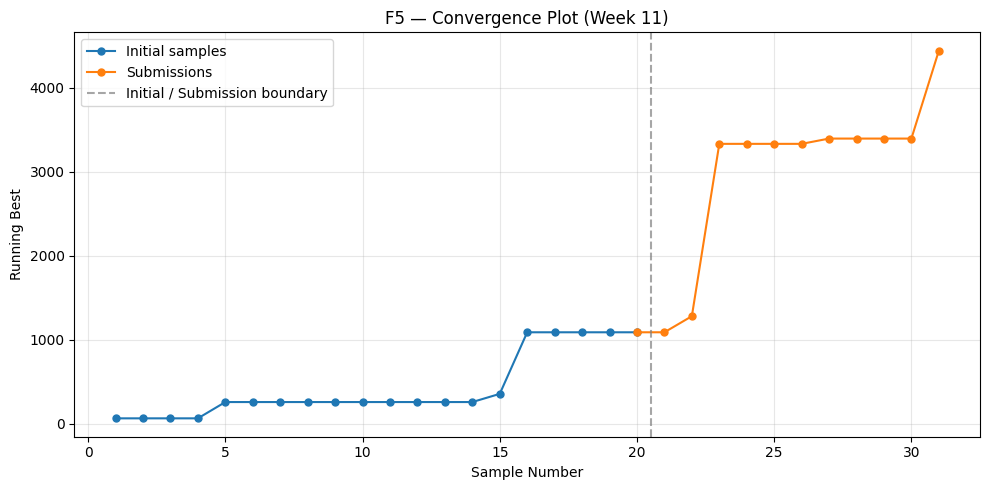

In [23]:
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))
x_all = np.arange(1, n_total + 1)

ax.plot(x_all[:N_INITIAL], running_best[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)
ax.plot(x_all[N_INITIAL-1:], running_best[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_ylabel('Running Best')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue**, submission samples in **orange** (numbered by week).

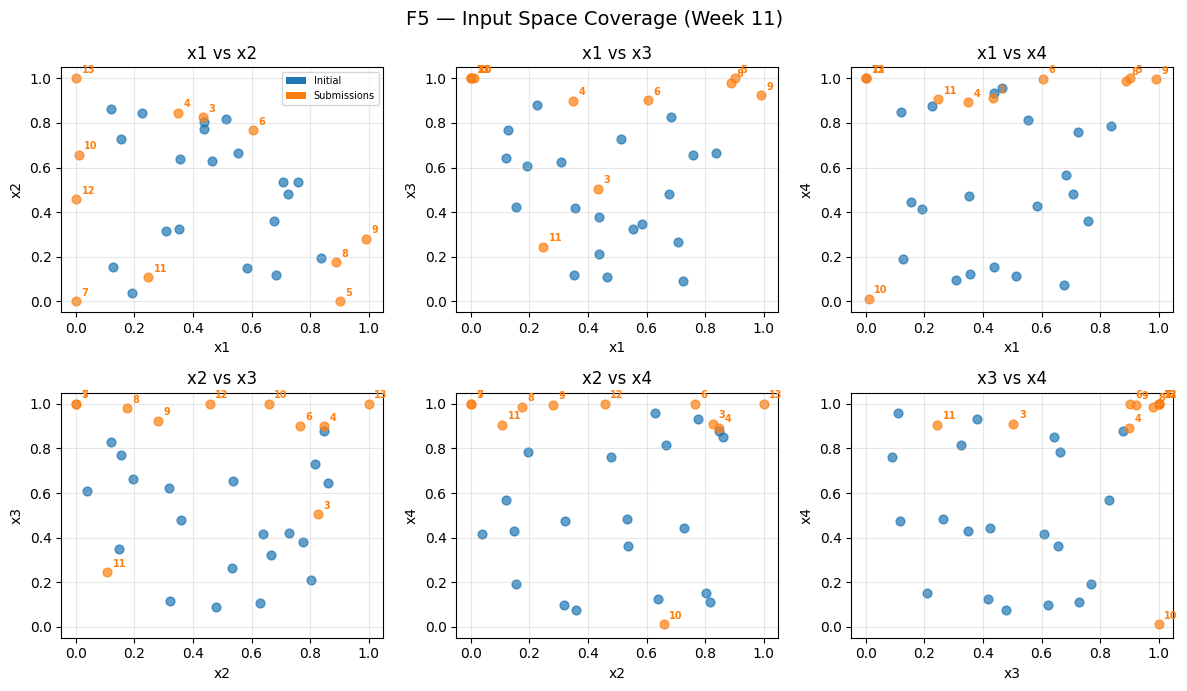

In [24]:
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5)
n_rows = math.ceil(n_pairs / n_cols)
fig_width = n_cols * 4
fig_height = n_rows * 3.5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                         squeeze=False)

for idx, (di, dj) in enumerate(pairs):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
               c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

    for k in range(N_INITIAL, n_total):
        week_num = k - N_INITIAL + 3
        ax.scatter(inputs[k, di], inputs[k, dj],
                   c='tab:orange', marker='o', s=40, alpha=0.7)
        ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                    textcoords='offset points', xytext=(4, 4),
                    fontsize=7, color='tab:orange', fontweight='bold')

    ax.set_xlabel(f'x{di+1}')
    ax.set_ylabel(f'x{dj+1}')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'x{di+1} vs x{dj+1}')
    ax.grid(True, alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                   Patch(facecolor='tab:orange', label='Submissions')]
axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

for idx in range(n_pairs, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].set_visible(False)

fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
fig.tight_layout()
plt.show()

## Step 4 — Performance Evaluation

### Week 10 Strategy

- **Surrogate**: GP Matérn-1.5 ARD + log transform + Standardize(m=1)
- **Acquisition**: qLogNEI q=4 + 60 MLL restarts + 8000 raw samples
- **Key changes**: Added interior penalty (removed week 10 as it was too aggressive), 60 MLL restarts for stability

### Performance Summary

In [25]:
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     1088.86
Best value (final):       4440.48
Improvements:             4/11
Max consecutive no-improve: 3
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |        438.991 |        1088.86 | ✗
   4 |        1280.36 |        1280.36 | ✓
   5 |         3331.8 |         3331.8 | ✓
   6 |        1966.52 |         3331.8 | ✗
   7 |        1616.63 |         3331.8 | ✗
   8 |        2868.52 |         3331.8 | ✗
   9 |        3394.68 |        3394.68 | ✓
  10 |        357.081 |        3394.68 | ✗
  11 |        30.5401 |        3394.68 | ✗
  12 |        1718.02 |        3394.68 | ✗
  13 |        4440.48 |        4440.48 | ✓


## Step 5 — Strategy Proposals for Next Submission

Review the performance metrics and convergence plot above. Key considerations for F5:

1. **F5 has all-positive, large-magnitude outputs** (range ~1088–3394). The log transform is appropriate and should be retained.

2. **If week 11 improved**: The GP Matérn-1.5 + log transform is working. To maintain momentum:
   - Keep the same surrogate configuration
   - Consider reducing q from 4 to 2 to focus more tightly around the improving region
   - Increase MLL restarts to 80 for more reliable hyperparameter fits as data grows

3. **If week 11 did NOT improve**: Interior penalty was removed in week 10 — evaluate whether re-adding it with milder parameters helps:
   - **Re-add interior penalty** with lower steepness (STEEPNESS=0.01, MARGIN=0.05) to gently guide away from boundaries
   - **Try Matérn-2.5** instead of 1.5 — smoother interpolation may help in the large-output regime
   - **Increase raw_samples to 10000** for better 4D coverage
   - **ARD lengthscale inspection**: Check if the GP model has identified irrelevant dimensions — if so, remove them

4. **General**: F5 has 3/10 improvements — moderate performance. The output scale is large and positive, which log transform handles well. The key question is whether the function has localised optima or a broad high-value region.

## ARD Feature Relevance Analysis

Automatic Relevance Determination (ARD) assigns a separate lengthscale parameter to each input dimension in the GP kernel. **Smaller lengthscale → the model is more sensitive to that dimension → higher relevance.**

Below we fit a SingleTaskGP with a Matérn-1.5 ARD kernel on the current data, extract the per-dimension lengthscales, and visualise the normalised relevance scores. The output transform matches the optimisation notebook: log(y) then Standardize(m=1).

In [ ]:
import torch
import gpytorch
from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.priors import GammaPrior
from gpytorch.constraints import GreaterThan

# Prepare training data (match optimisation notebook transform: log(y) then Standardize)
X_train = torch.tensor(inputs, dtype=torch.float64)
Y_train = torch.log(torch.tensor(outputs, dtype=torch.float64).unsqueeze(-1))

# Fit SingleTaskGP with Matérn-1.5 ARD kernel
covar_module = ScaleKernel(
    MaternKernel(nu=1.5, ard_num_dims=N_DIMS, lengthscale_prior=GammaPrior(3.0, 6.0)),
    outputscale_prior=GammaPrior(2.0, 0.15),
)
model = SingleTaskGP(X_train, Y_train, covar_module=covar_module, outcome_transform=Standardize(m=1))
model.likelihood.noise_covar.register_constraint("raw_noise", GreaterThan(1e-6))
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_mll(mll)

# Extract ARD lengthscales
lengthscales = model.covar_module.base_kernel.lengthscale.detach().squeeze().numpy()
dim_names = ["x1", "x2", "x3", "x4"]

print(f"F{FUNC_NUM}: ARD Lengthscales (Matérn-1.5 kernel)")
print(f"{'Dimension':<15} {'Lengthscale':>12}")
print("-" * 28)
for name, ls in zip(dim_names, lengthscales):
    print(f"{name:<15} {ls:>12.6f}")